In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "6"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
from sqlalchemy import create_engine
import urllib

# Configura la conexión
from dotenv import load_dotenv
import os

load_dotenv() # busca ".env" en el directorio actual (o directorios superiores) y carga sus variables

server = os.environ.get('DB_SERVER')
database = os.environ.get('DB_NAME')
username = os.environ.get('DB_USER')
password = os.environ.get('DB_PASSWORD')

driver = 'ODBC Driver 17 for SQL Server'  # Verifica que tengas este driver instalado

params = urllib.parse.quote_plus(
    f'DRIVER={{{driver}}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'UID={username};'
    f'PWD={password}'
)


In [18]:

engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')

query = "SELECT [plate],[NTrans],[AvgMinutes],[TotalAmount],[LM60]+[LT60]+[LM120]+[LT120] [L120],[LM320]+[LT320] [L320],[LMRest]+[LTRest] [LRest],[F60]+[F120]+[F320]+[FRest] [FT],[Age],[Tag],[DigTrans] FROM [ESPDM].[dbo].[ParkingTransSummaryEnriched] where [IDPK] = 'PKSA' and [NTrans] > 5"

df = pd.read_sql(query, engine)

print(df.head())


     plate  NTrans  AvgMinutes  TotalAmount  L120  L320  LRest  FT    Age  \
0  0001JLJ       7         519       101.55     0     0      6   1  10.58   
1  0001MKS      12         237        82.00     3     6      3   0   2.83   
2  0003MYG       8          70        16.90     7     1      0   0   1.50   
3  0004JTW       6          92        16.70     5     1      0   0   9.75   
4  0009FYT      11          80        25.90    10     1      0   0  18.67   

   Tag  DigTrans  
0    3         0  
1    3         0  
2    1         0  
3    3         0  
4    2         0  


In [19]:
df.describe()

,NTrans,AvgMinutes,TotalAmount,L120,L320,LRest,FT,Age,Tag,DigTrans
count,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000,2737.000000
mean,10.459262,116.388381,33.868414,7.310559,2.658020,0.353307,0.111801,12.990607,2.625868,0.377055
std,7.514939,127.137287,34.610168,6.419771,3.389759,1.362530,0.392635,7.086209,0.894854,5.762695
min,6.000000,6.000000,5.250000,0.000000,0.000000,0.000000,0.000000,1.250000,0.000000,0.000000
25%,7.000000,68.000000,16.650000,4.000000,1.000000,0.000000,0.000000,7.090000,2.000000,0.000000
50%,8.000000,92.000000,24.750000,6.000000,2.000000,0.000000,0.000000,12.080000,3.000000,0.000000
75%,11.000000,129.000000,38.450000,8.000000,4.000000,0.000000,0.000000,19.250000,3.000000,0.000000
max,115.000000,3097.000000,672.200000,110.000000,46.000000,34.000000,5.000000,25.830000,4.000000,271.000000


C:\Users\jframirez\AppData\Local\Temp\ipykernel_41072\533375319.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.drop('plate', axis=1).hist(ax=ax)


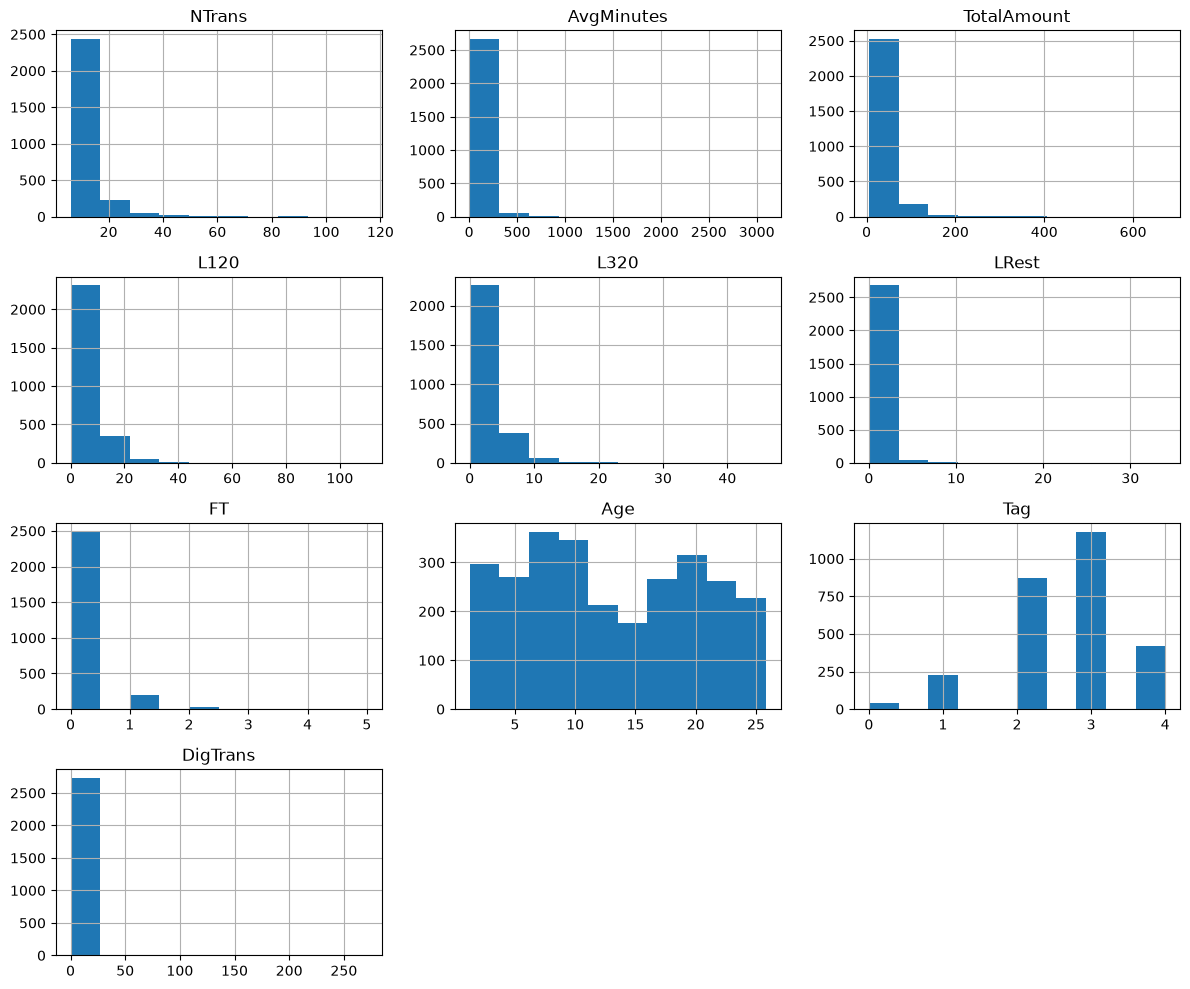

In [20]:
fig, ax = plt.subplots(figsize=(12, 10))

# Removing the customer's id before plotting the distributions
df.drop('plate', axis=1).hist(ax=ax)

plt.tight_layout()
plt.show()

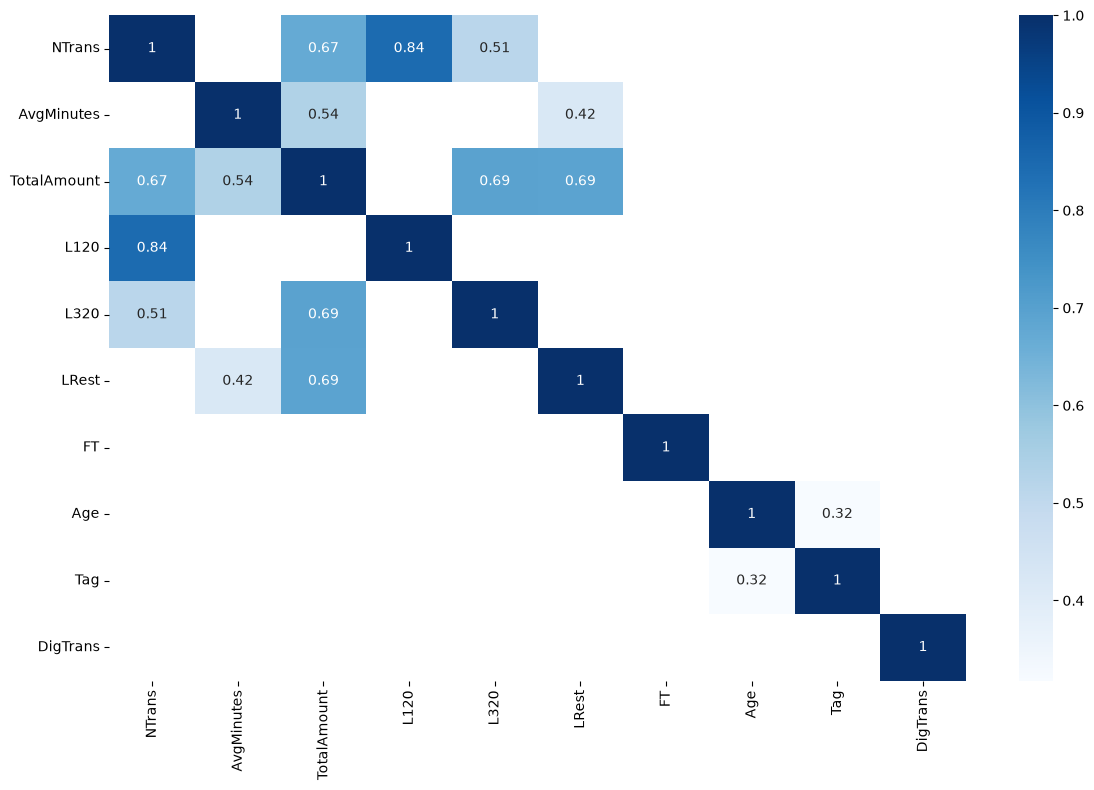

In [21]:
correlations = df.drop('plate', axis=1).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(correlations[(correlations > 0.30) | (correlations < -0.30)],
            cmap='Blues', annot=True, ax=ax)

plt.tight_layout()
plt.show()

In [22]:
X = df.drop('plate', axis=1)

scaler = StandardScaler()
scaler.fit(X)

X_scaled = scaler.transform(X)

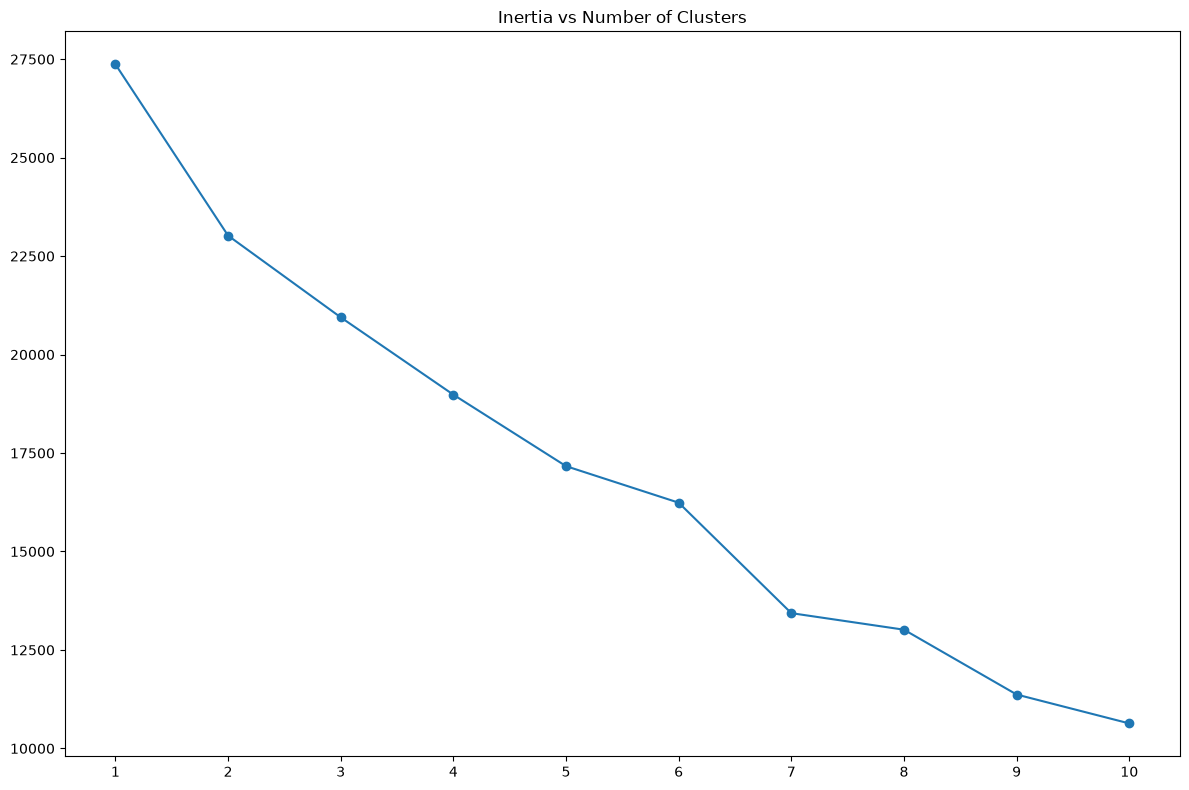

In [23]:
X = pd.DataFrame(X_scaled)
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k)
    y = model.fit_predict(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), inertias, marker='o')
plt.xticks(ticks=range(1, 11), labels=range(1, 11))
plt.title('Inertia vs Number of Clusters')

plt.tight_layout()
plt.show()

In [28]:
model = KMeans(n_clusters=6)
y = model.fit_predict(X_scaled)

# Adding the cluster assignments to our original dataframe
df['CLUSTER'] = y + 1  # Adding 1 to make clusters 1-based instead of 0-based
# df.head()

In [29]:
df['CLUSTER'].value_counts()

CLUSTER
4    1244
2     910
6     260
1     209
3      99
5      15
Name: count, dtype: int64

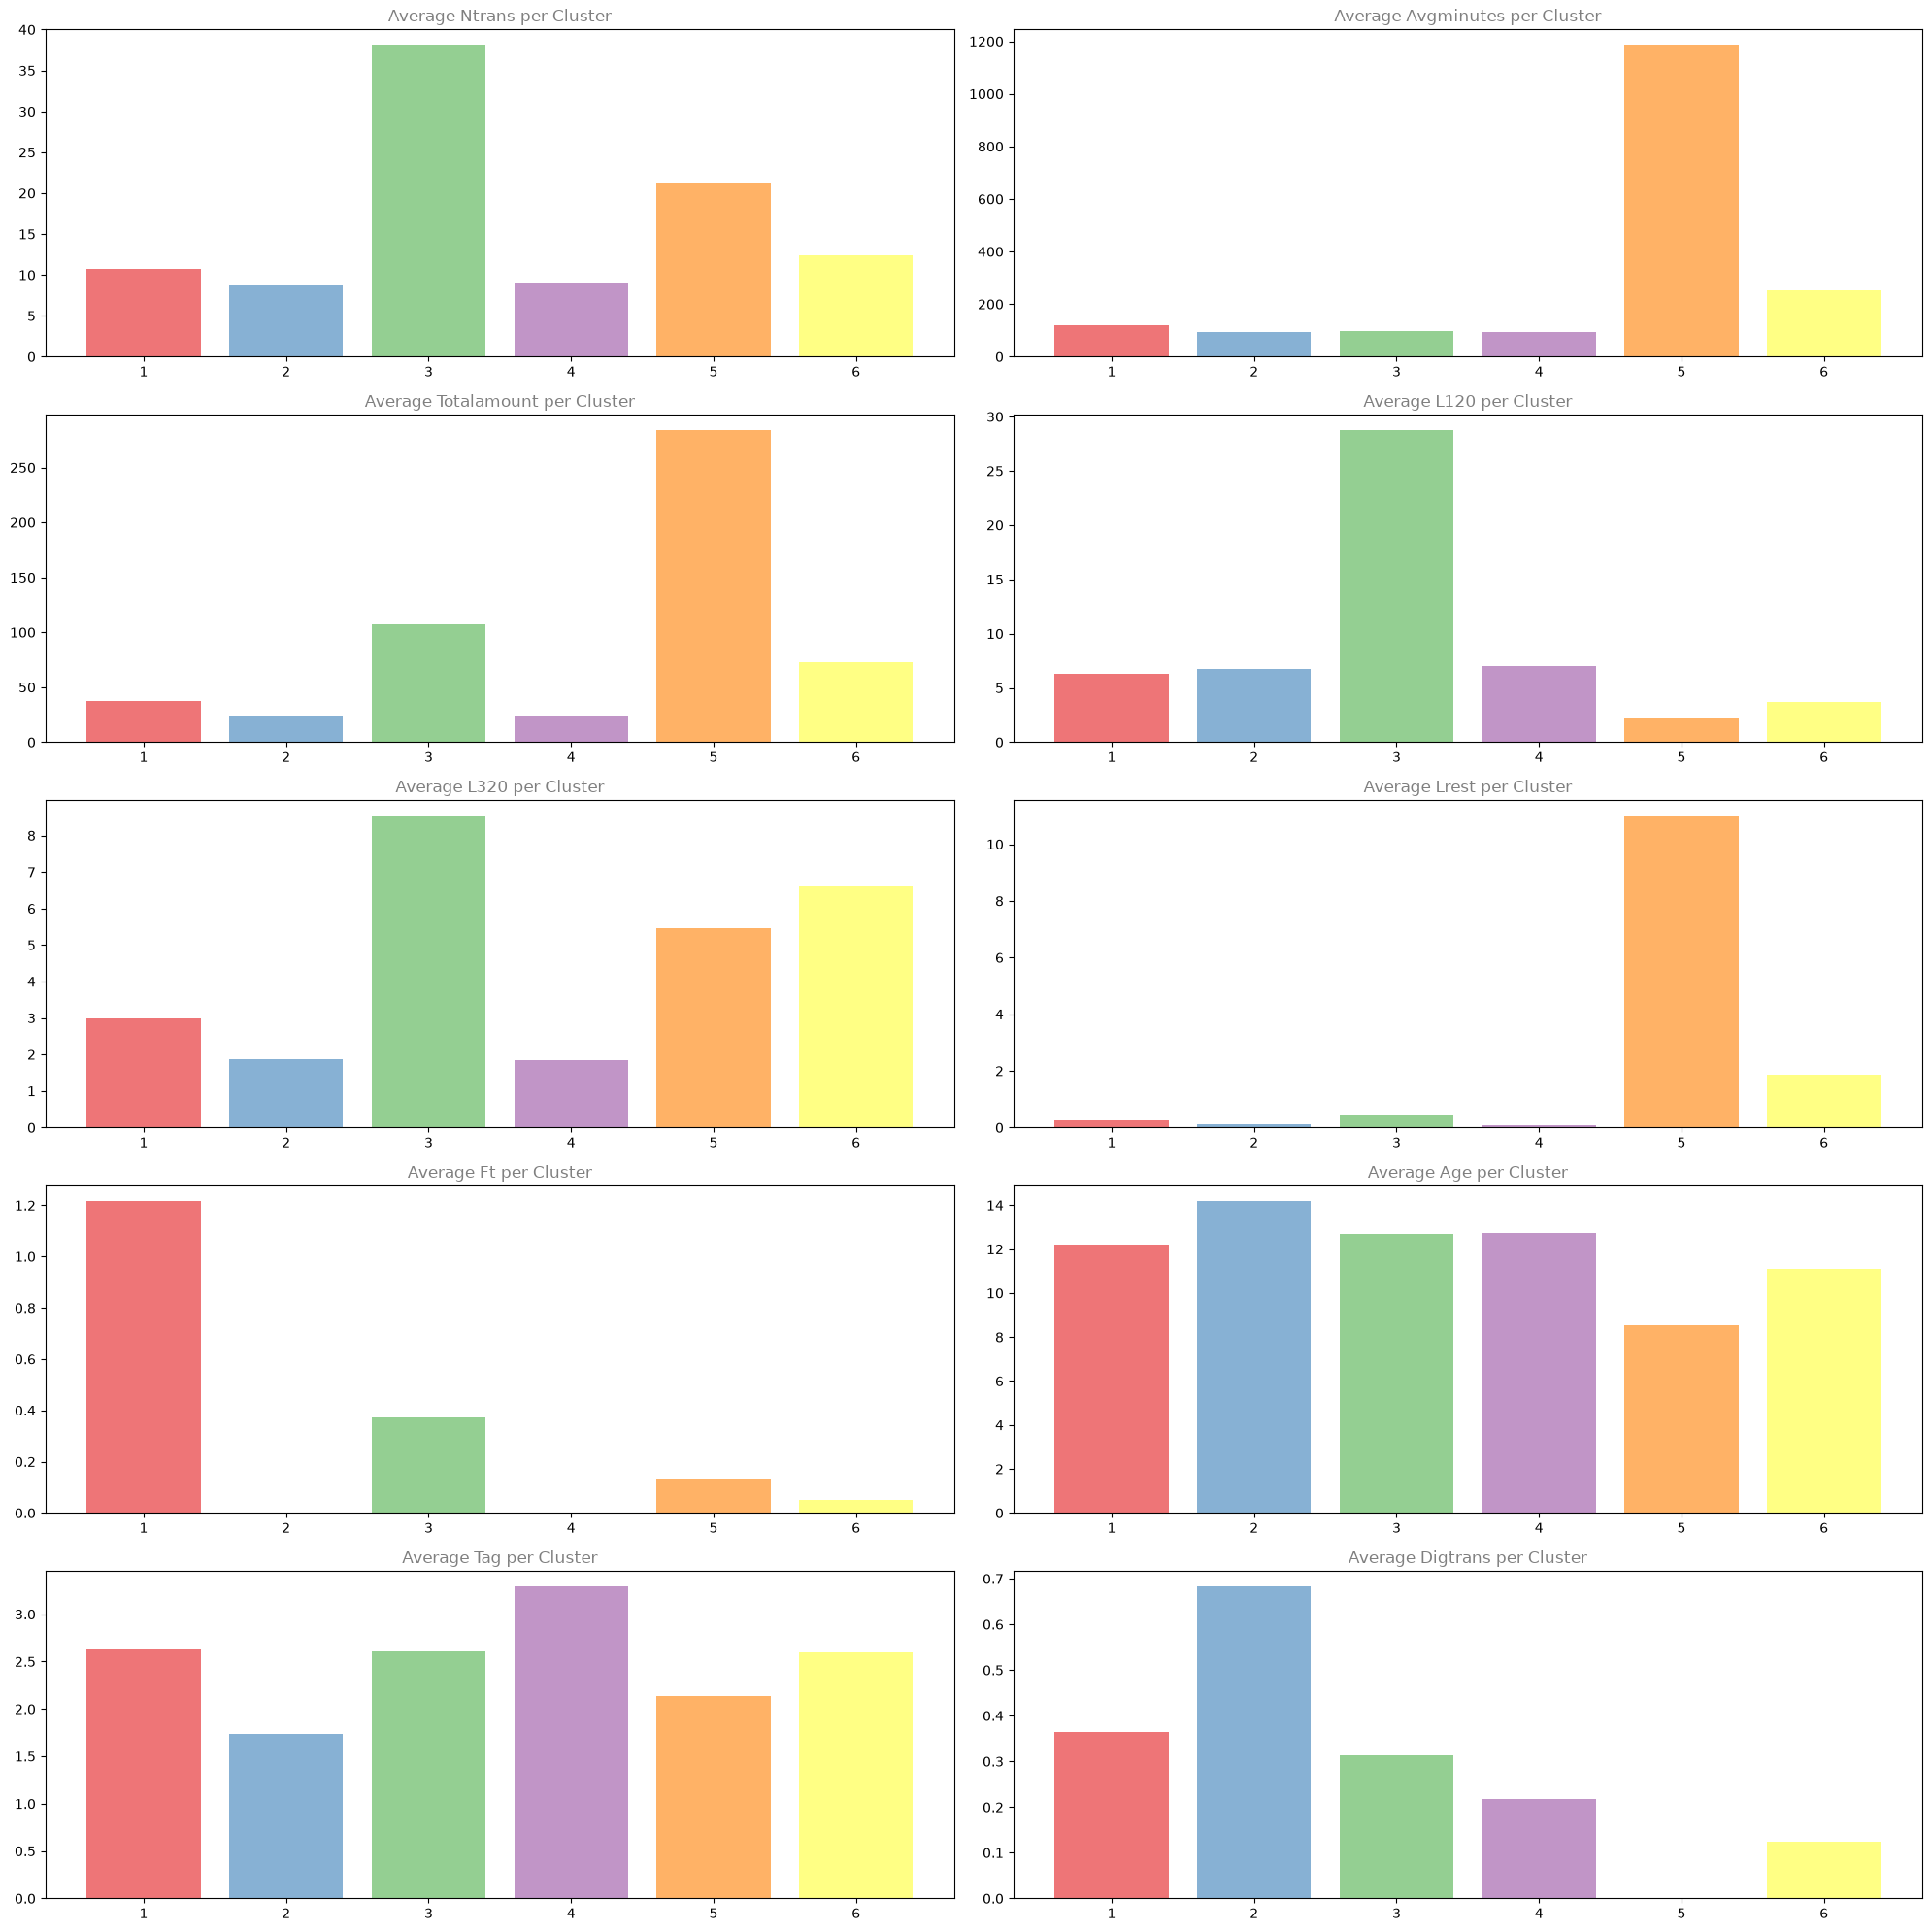

In [32]:
numeric_columns = df.select_dtypes(include=np.number).drop(['CLUSTER'], axis=1).columns

fig = plt.figure(figsize=(20, 20))
for i, column in enumerate(numeric_columns):
    df_plot = df.groupby('CLUSTER')[column].mean()
    ax = fig.add_subplot(5, 2, i+1)
    ax.bar(df_plot.index, df_plot, color=sns.color_palette('Set1'), alpha=0.6)
    ax.set_title(f'Average {column.title()} per Cluster', alpha=0.5)
    ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

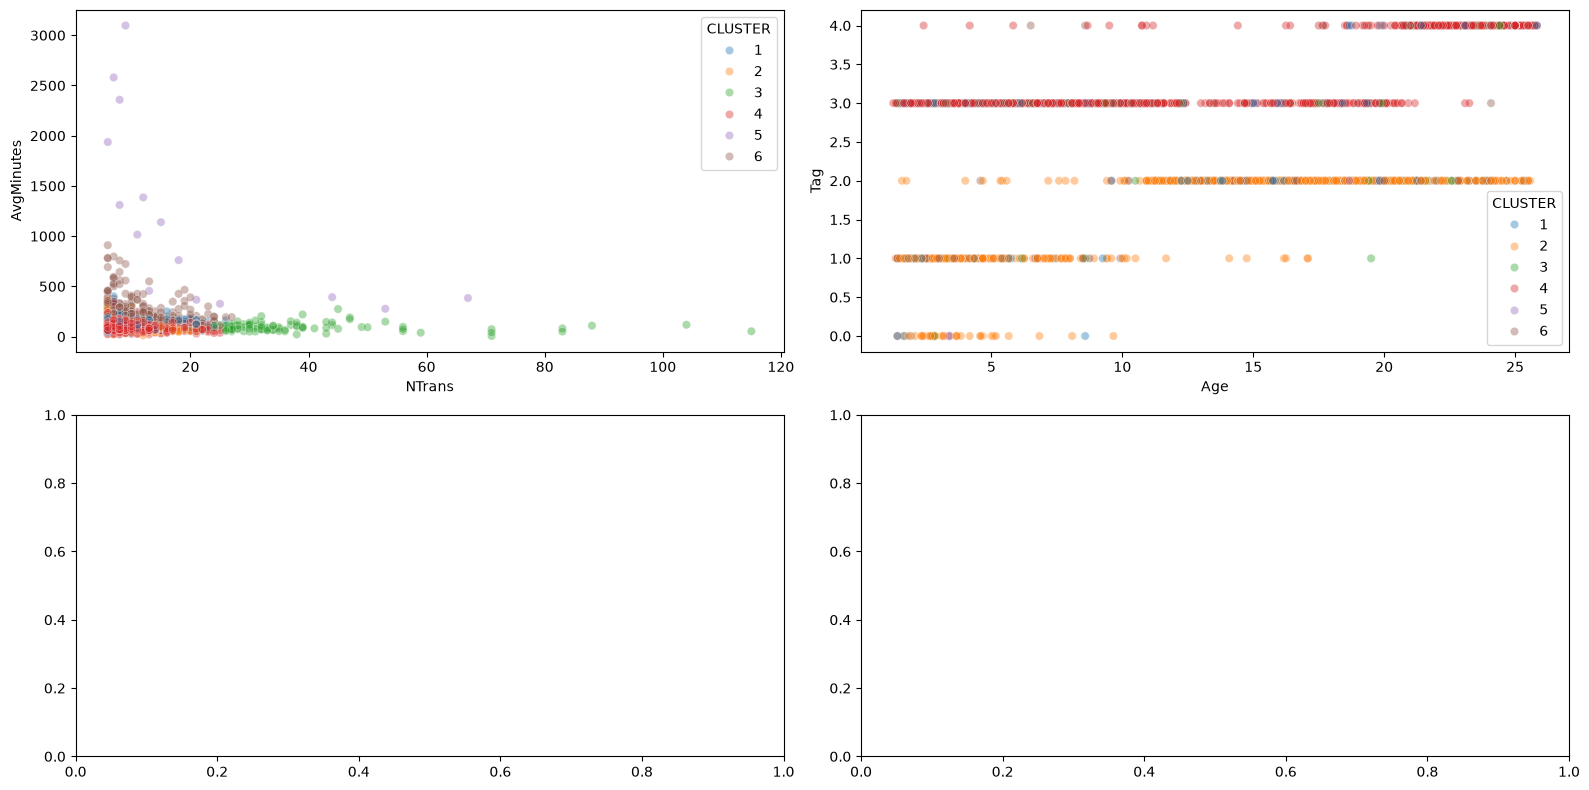

In [33]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))
sns.scatterplot(x='NTrans', y='AvgMinutes', hue='CLUSTER', data=df, palette='tab10', alpha=0.4, ax=ax1)
sns.scatterplot(x='Age', y='Tag', hue='CLUSTER', data=df, palette='tab10', alpha=0.4, ax=ax2)

plt.tight_layout()
plt.show()